#IMPORTS

In [ ]:
!pip install scikeras
!pip install tensorflow

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np # Import numpy for potential future use

from matplotlib import pyplot as plt

import h5py
import json
from numpy import argwhere

from sklearn.model_selection import train_test_split
import numpy as np

from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import numpy as np


import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, Flatten, Dense, Dropout
from tensorflow.keras.callbacks import ModelCheckpoint
from scikeras.wrappers import KerasClassifier
from sklearn.model_selection import GridSearchCV
import threading # Usaremos threading para garantir a segurança da thread
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.

import numpy as np
import tensorflow as tf
from tensorflow import keras
from scikeras.wrappers import KerasClassifier
from sklearn.model_selection import GridSearchCV, train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, Dropout, Flatten, Dense
from tensorflow.keras.optimizers import Adam, SGD
from sklearn.model_selection import RandomizedSearchCV
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt


In [ ]:
# Before creating the plot, set the desired font size and name
plt.rcParams['font.size'] = 12  # Change the default font size
plt.rcParams['font.family'] = 'serif'  # Change the default font family (e.g., 'serif', 'sans-serif', 'monospace')

# You can also change these settings for specific text elements if needed.
# For example, to change the title font size:
# plt.title('Plot Title', fontsize=16)


#DATASET LOCAL

In [ ]:
path = '/Users/Administrador/Dropbox/ML_radio/archive'
h5py_path = path + '/GOLD_XYZ_OSC.0001_1024.hdf5'
modulation_classes_path = path + '/classes-fixed.json'


# Open the dataset
hdf5_file = h5py.File(h5py_path, 'r')
# Load the modulation classes. You can also copy and paste the content of classes-fixed.txt.
modulation_classes = json.load(open(modulation_classes_path, 'r'))

# Read the HDF5 groups
data = hdf5_file['X']
modulation_onehot = hdf5_file['Y']
snr = hdf5_file['Z']

FileNotFoundError: [Errno 2] Unable to synchronously open file (unable to open file: name = '/Users/Administrador/Dropbox/ML_radio/archive/GOLD_XYZ_OSC.0001_1024.hdf5', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)

In [ ]:
# Load all data from the datasets in the HDF5 file
X = data
Y = modulation_onehot
Z = snr

# Convert one-hot encoded labels to numerical labels
y = np.argmax(Y, axis=1)

#IMPORT DATASET

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("pinxau1000/radioml2018")

print("Path to dataset files:", path)

h5py_path = path + '/GOLD_XYZ_OSC.0001_1024.hdf5'
modulation_classes_path = path + '/classes-fixed.json'
# Open the dataset
hdf5_file = h5py.File(h5py_path, 'r')
# Load the modulation classes. You can also copy and paste the content of classes-fixed.txt.
modulation_classes = json.load(open(modulation_classes_path, 'r'))

# Read the HDF5 groups
data = hdf5_file['X']
modulation_onehot = hdf5_file['Y']
snr = hdf5_file['Z']

Using Colab cache for faster access to the 'radioml2018' dataset.
Path to dataset files: /kaggle/input/radioml2018


In [ ]:
# Load all data from the datasets in the HDF5 file
X = data
Y = modulation_onehot
Z = snr

# Convert one-hot encoded labels to numerical labels
y = np.argmax(Y, axis=1)

#DEFS


In [ ]:


def get_indices_by_snr(target_snrs):
    """
    Separates and returns indices corresponding to specified SNR values.

    Args:
        target_snrs (list or np.ndarray): A list or array of SNR values
                                          (e.g., [-20, -10, 0, 10]) to filter by.

    Returns:
        np.ndarray: A sorted numpy array of indices from the original dataset (X, Y, Z, y)
                    where the SNR matches one of the target_snrs.
    """
    # Convert target_snrs to a set for efficient lookup
    target_snrs_set = set(target_snrs)

    # Get the SNR values from the Z array (assuming Z is globally available)
    # Z[:, 0] extracts the SNR column
    all_snr_values = Z[:, 0]

    # Find indices where the SNR value is in the target_snrs_set
    matching_indices = np.where(np.isin(all_snr_values, list(target_snrs_set)))[0]

    return np.sort(matching_indices)

# Example Usage:
# Let's say you want indices for SNR values of -20dB, 0dB, and 10dB
# desired_snrs = [-20, 0, 10]
# selected_snr_indices = get_indices_by_snr(desired_snrs)
#
# print(f"Found {len(selected_snr_indices)} samples with SNR in {desired_snrs}")
#
# # You can then use these indices to access the corresponding data
# # X_filtered_by_snr = X[selected_snr_indices]
# # y_filtered_by_snr = y[selected_snr_indices]
# # Z_filtered_by_snr = Z[selected_snr_indices]

# The previous content of this cell was likely a print statement.
# I'll add a simple print to confirm the function is defined.


In [ ]:
def get_samples_by_snr(target_snrs):
    """
    Returns data samples (X, Y, Z, y) corresponding to specified SNR values.

    Args:
        target_snrs (list or np.ndarray): A list or array of SNR values
                                          (e.g., [-20, -10, 0, 10]) to filter by.

    Returns:
        tuple: A tuple containing X_filtered, Y_filtered, Z_filtered, y_filtered
               for the selected SNR values.
    """
    # Use the existing function to get indices for the target SNRs
    selected_indices = get_indices_by_snr(target_snrs)

    # Use these indices to subset the global data arrays
    X_filtered = X[selected_indices]
    Y_filtered = Y[selected_indices]
    Z_filtered = Z[selected_indices]
    y_filtered = y[selected_indices]

    print(f"\nSubset created with {len(selected_indices)} samples for SNR values: {target_snrs}.")
    print(f"Shape of X_filtered: {X_filtered.shape}")
    print(f"Shape of Y_filtered: {Y_filtered.shape}")
    print(f"Shape of Z_filtered: {Z_filtered.shape}")
    print(f"Shape of y_filtered: {y_filtered.shape}")

    return X_filtered, Y_filtered, Z_filtered, y_filtered, selected_indices

print("Function 'get_samples_by_snr' defined.")

Function 'get_samples_by_snr' defined.


In [ ]:
def subset_snr (target_snrs, frac):
    X_snr, Y_snr, Z_snr, y_snn, selected_indices = get_samples_by_snr(target_snrs)

    ind_snr_frac, ind_lixo, Y_snr_frac, Ysnr_lixo = train_test_split(
        selected_indices,
        Y_snr,
        test_size=1-frac,
        random_state=42,
        stratify=Y_snr
    )

    ind_snr_frac = np.sort(ind_snr_frac)
    X_filtered = X[ind_snr_frac]
    Y_filtered = Y[ind_snr_frac]
    Z_filtered = Z[ind_snr_frac]
    y_filtered = y[ind_snr_frac]

    print(f"\nSubset created with {len(selected_indices)} samples for SNR values: {target_snrs}.")
    print(f"Shape of X_filtered: {X_filtered.shape}")
    print(f"Shape of Y_filtered: {Y_filtered.shape}")
    print(f"Shape of Z_filtered: {Z_filtered.shape}")
    print(f"Shape of y_filtered: {y_filtered.shape}")

    return X_filtered, Y_filtered, Z_filtered, y_filtered, ind_snr_frac





In [ ]:
def split (indices, lables):
  train_val_indices, test_indices, train_val_lables, test_lables = train_test_split(
        indices,
        lables,
        test_size=0.2,
        random_state=42,
        stratify=lables
    )

  train_indices, val_indices, train_lables, val_lables = train_test_split(
        train_val_indices,
        train_val_lables,
        test_size=0.25,
        random_state=42,
        stratify=train_val_lables
    )

  train_indices_sorted = np.sort(train_indices)
  val_indices_sorted = np.sort(val_indices)
  test_indices_sorted = np.sort(test_indices)

  return train_indices_sorted, val_indices_sorted, test_indices_sorted

#SUBSET

In [ ]:
# Exemplo: Obter amostras com SNR de 0dB, 10dB e 20dB
desired_snrs_example = [10, 20, 30]
X_subset, Y_subset, Z_subset, y_subset, selected_indices = subset_snr(desired_snrs_example,0.01)

print(f"\nPrimeiras 5 classes (y) dos dados filtrados:\n{y_subset[1500]}")
print(f"Primeiros 5 valores de SNR (Z) dos dados filtrados:\n{Z_subset[:5]}")


Subset created with 294912 samples for SNR values: [10, 20, 30].
Shape of X_filtered: (294912, 1024, 2)
Shape of Y_filtered: (294912, 24)
Shape of Z_filtered: (294912, 1)
Shape of y_filtered: (294912,)

Subset created with 294912 samples for SNR values: [10, 20, 30].
Shape of X_filtered: (2949, 1024, 2)
Shape of Y_filtered: (2949, 24)
Shape of Z_filtered: (2949, 1)
Shape of y_filtered: (2949,)

Primeiras 5 classes (y) dos dados filtrados:
12
Primeiros 5 valores de SNR (Z) dos dados filtrados:
[[10]
 [10]
 [10]
 [10]
 [10]]


In [ ]:
indices = selected_indices#_sorted
lables = y_subset
train_indices_sorted, val_indices_sorted, test_indices_sorted = split(indices, lables)

In [ ]:
X_train = X[train_indices_sorted]
X_val = X[val_indices_sorted]
X_test = X[test_indices_sorted]

y_train = y[train_indices_sorted]
y_val = y[val_indices_sorted]
y_test = y[test_indices_sorted]

In [ ]:
X_train_reshaped = X_train.reshape(X_train.shape[0], -1)
X_val_reshaped = X_val.reshape(X_val.shape[0], -1)
X_test_reshaped = X_test.reshape(X_test.shape[0], -1)

print(f"Shape of X_train after reshaping: {X_train_reshaped.shape}")
print(f"Shape of X_val after reshaping: {X_val_reshaped.shape}")
print(f"Shape of X_test after reshaping: {X_test_reshaped.shape}")

Shape of X_train after reshaping: (1769, 2048)
Shape of X_val after reshaping: (590, 2048)
Shape of X_test after reshaping: (590, 2048)


#SET TOTAL

In [ ]:
num_samples = X.shape[0]
indices = np.arange(num_samples) #selected_indices_sorted
lables = np.column_stack((y, Z))

train_indices_sorted, val_indices_sorted, test_indices_sorted = split(indices, lables)

#MLP

In [ ]:
param_grid = {
    'hidden_layer_sizes': [(50,), (100,), (50, 50),(50,50,50),(100,100)],
    'activation': ['tanh', 'relu'],
    'solver': ['adam', 'sgd'],
    'alpha': [0.0005, 0.0001, 0.001, 0.01]
}

In [ ]:
from sklearn.neural_network import MLPClassifier

model = MLPClassifier(random_state=42, verbose=True)
print("MLPClassifier instantiated with default parameters.")

MLPClassifier instantiated with default parameters.


In [ ]:
from sklearn.model_selection import GridSearchCV

# Instantiate the GridSearchCV object
grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=3, n_jobs=-1, verbose=1)

# Fit the grid search to the training data
grid_search.fit(X_train_reshaped, y_train)

# Print the best hyperparameters found
print("Best hyperparameters found:")
print(grid_search.best_params_)

# Print the best cross-validation score achieved
print("Best cross-validation score:")
print(grid_search.best_score_)

Fitting 3 folds for each of 80 candidates, totalling 240 fits
Iteration 1, loss = 3.69753372
Iteration 2, loss = 3.22667607
Iteration 3, loss = 2.91621524
Iteration 4, loss = 2.78452381
Iteration 5, loss = 2.62261812
Iteration 6, loss = 2.47761763
Iteration 7, loss = 2.46487589
Iteration 8, loss = 2.17267456
Iteration 9, loss = 2.01875868
Iteration 10, loss = 1.91277482
Iteration 11, loss = 1.81548985
Iteration 12, loss = 1.77289969
Iteration 13, loss = 1.64536575
Iteration 14, loss = 1.50279673
Iteration 15, loss = 1.30810406
Iteration 16, loss = 1.19889782
Iteration 17, loss = 1.13099367
Iteration 18, loss = 1.01249955
Iteration 19, loss = 1.06272105
Iteration 20, loss = 1.01356186
Iteration 21, loss = 0.83623251
Iteration 22, loss = 0.84172614
Iteration 23, loss = 0.73388465
Iteration 24, loss = 0.73021791
Iteration 25, loss = 0.54522238
Iteration 26, loss = 0.59205527
Iteration 27, loss = 0.46725189
Iteration 28, loss = 0.47060345
Iteration 29, loss = 0.50337431
Iteration 30, loss 

In [ ]:
best_model= grid_search.best_estimator_


In [ ]:
best_model.fit(X_train_reshaped, y_train)

Iteration 1, loss = 3.69753372
Iteration 2, loss = 3.22667607
Iteration 3, loss = 2.91621524
Iteration 4, loss = 2.78452381
Iteration 5, loss = 2.62261812
Iteration 6, loss = 2.47761763
Iteration 7, loss = 2.46487589
Iteration 8, loss = 2.17267456
Iteration 9, loss = 2.01875868
Iteration 10, loss = 1.91277482
Iteration 11, loss = 1.81548985
Iteration 12, loss = 1.77289969
Iteration 13, loss = 1.64536575
Iteration 14, loss = 1.50279673
Iteration 15, loss = 1.30810406
Iteration 16, loss = 1.19889782
Iteration 17, loss = 1.13099367
Iteration 18, loss = 1.01249955
Iteration 19, loss = 1.06272105
Iteration 20, loss = 1.01356186
Iteration 21, loss = 0.83623251
Iteration 22, loss = 0.84172614
Iteration 23, loss = 0.73388465
Iteration 24, loss = 0.73021791
Iteration 25, loss = 0.54522238
Iteration 26, loss = 0.59205527
Iteration 27, loss = 0.46725189
Iteration 28, loss = 0.47060345
Iteration 29, loss = 0.50337431
Iteration 30, loss = 0.44494415
Iteration 31, loss = 0.40215410
Iteration 32, los

MLPClassifier(alpha=0.0005, hidden_layer_sizes=(100, 100), random_state=42,
              verbose=True)

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

# Retrieve the best model
#best_model = grid_search.best_estimator_

# Predict on the test set
y_pred = best_model.predict(X_test_reshaped)

# Calculate and print accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {accuracy}")

# Generate and print classification report
print("Classification Report:")
# Fix: Remove target_names or use labels=np.unique(y_test) to match the actual classes in y_test
print(classification_report(y_test, y_pred, labels=np.unique(y_test), target_names=[str(i) for i in np.unique(y_test)]))

# Generate and print confusion matrix
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Test Accuracy: 0.17457627118644067
Classification Report:
              precision    recall  f1-score   support

           0       0.20      0.17      0.18        24
           1       0.30      0.29      0.30        24
           2       0.08      0.08      0.08        25
           3       0.12      0.12      0.12        25
           4       0.03      0.04      0.04        24
           5       0.04      0.04      0.04        25
           6       0.05      0.04      0.04        25
           7       0.06      0.08      0.07        25
           8       0.09      0.08      0.08        25
           9       0.00      0.00      0.00        24
          10       0.03      0.04      0.04        24
          11       0.17      0.12      0.14        24
          12       0.00      0.00      0.00        25
          13       0.00      0.00      0.00        25
          14       0.00      0.00      0.00        24
          15       0.05      0.04      0.04        25
          16       0.16

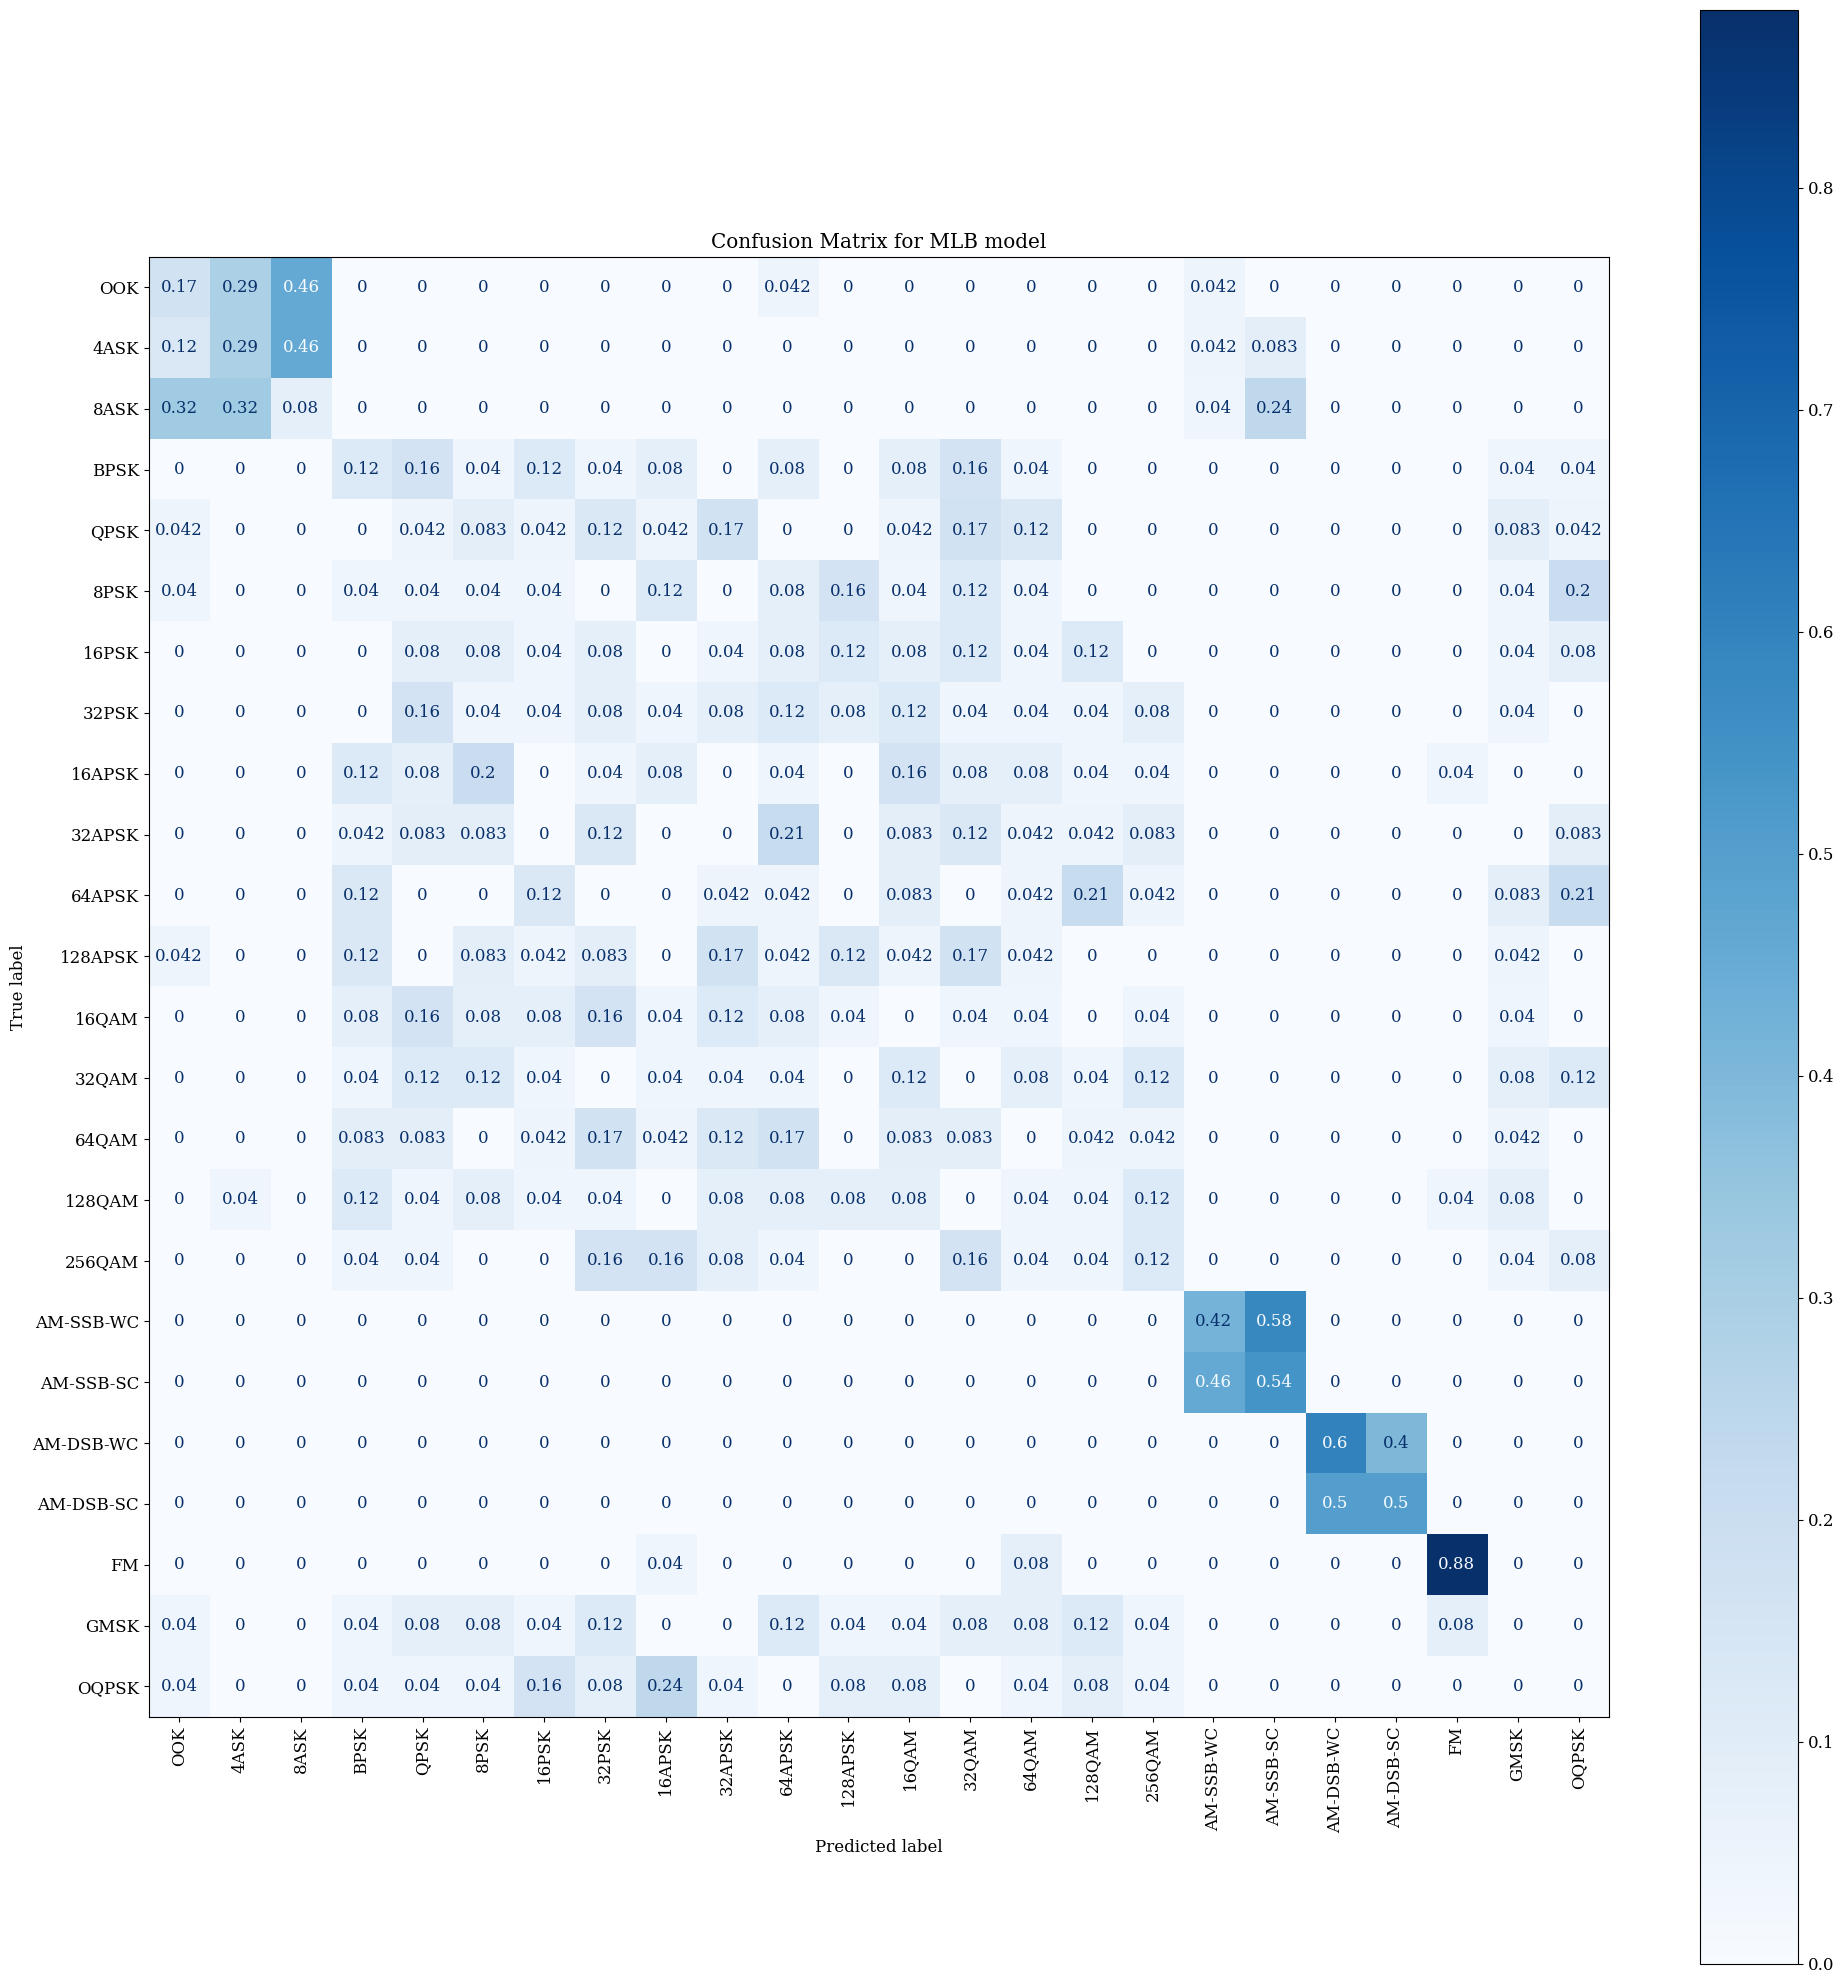

In [ ]:


fig, ax = plt.subplots(figsize=(20, 20))
cmd = ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap=plt.cm.Blues, ax=ax, normalize='true', display_labels=modulation_classes)
ax.set_title('Confusion Matrix for MLB model')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

#LGB

In [ ]:
import lightgbm as lgb
from scipy.stats import randint, uniform

lgb_train = lgb.Dataset(X_train_reshaped, y_train)
lgb_val = lgb.Dataset(X_val_reshaped, y_val, reference=lgb_train)

# Instantiate the LGBMClassifier with predefined parameters
model = lgb.LGBMClassifier(
    n_estimators=200,          # Chosen based on typical ranges
    learning_rate=0.05,        # Chosen based on typical ranges
    num_leaves=31,             # Common default, within previous search range
    max_depth=7,               # Chosen based on typical ranges
    subsample=0.85,            # Chosen based on typical ranges
    colsample_bytree=0.8,      # Chosen based on typical ranges
    reg_lambda=1.0,            # Common default, within previous search range
    random_state=42,
    verbose=1
)

# Define early stopping callback (still relevant for direct fitting)
early_stopping_callback = lgb.early_stopping(stopping_rounds=10, verbose=False)

# Pass eval_set and callbacks via fit_params dictionary
fit_params = {
    "eval_set": [(X_val_reshaped, y_val)],
    "callbacks": [early_stopping_callback]
}

print("LGBMClassifier instantiated with defined parameters.")

In [ ]:
model.fit(X_train_reshaped, y_train, **fit_params)

In [ ]:
# Fit the RandomizedSearchCV to the training data
#random_search.fit(X_train_reshaped, y_train, **fit_params_rs)

# Print the best hyperparameters found
#print("Best hyperparameters found by RandomizedSearchCV:")
#print(random_search.best_params_)

# Print the best cross-validation score
#print("Best cross-validation accuracy:", random_search.best_score_)

# Store the best model
#best_lgbm_model = random_search.best_estimator_
#print("LGBMClassifier model fitted and best estimator stored in `best_lgbm_model`.")


In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Predict on the test set using the best model found by RandomizedSearchCV
y_pred_lgbm = best_lgbm_model.predict(X_test_reshaped)

# Calculate and print accuracy
accuracy_lgbm = accuracy_score(y_test, y_pred_lgbm)
print(f"LGBM Test Accuracy: {accuracy_lgbm:.4f}")

# Generate and print classification report
print("\nLGBM Classification Report:")
print(classification_report(y_test, y_pred_lgbm, labels=np.unique(y_test), target_names=[str(i) for i in np.unique(y_test)]))

# Generate and print confusion matrix
print("\nLGBM Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_lgbm))


In [ ]:
fig, ax = plt.subplots(figsize=(20, 20))
cmd = ConfusionMatrixDisplay.from_predictions(y_test, y_pred_lgbm, cmap=plt.cm.Blues, ax=ax, normalize='true', display_labels=modulation_classes)
ax.set_title('Confusion Matrix for MLB model')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

#CNN


In [ ]:
class H5PyDataGenerator(tf.keras.utils.Sequence):

    def __init__ (self, h5_filepath, dataset_X_name, dataset_Y_name, dataset_Z_name, indices, batch_size,format):

        self.file = h5py.File(h5_filepath, 'r')

        self.X_data = self.file[dataset_X_name]
        self.Y_data = self.file[dataset_Y_name]
        self.Z_data = self.file[dataset_Z_name]

        self.indices = indices
        self.batch_size = batch_size
        self.on_epoch_end()
        self.format = format
    def __len__ (self):

        return int(np.floor(len(self.indices)/self.batch_size))

    def __getitem__(self, index):


        start_idx = index * self.batch_size
        end_idx = (index + 1) * self.batch_size

        # 1. Obtém os índices embaralhados para o batch atual
        batch_indices_shuffled = self.indices[start_idx:end_idx] # Agora start_idx e end_idx existem

        # 2. Obtém a ordem em que esses índices estão no disco (argsort)
        ordem_leitura = np.argsort(batch_indices_shuffled)

        # 3. Ordena os índices do batch para a leitura do H5PY
        indices_ordenados_h5py = batch_indices_shuffled[ordem_leitura]

        # 4. Lê os dados do H5PY usando os índices ordenados
        X_batch_ordenado = self.X_data[indices_ordenados_h5py, :]
        Y_batch_ordenado = self.Y_data[indices_ordenados_h5py]
        Z_batch_ordenadpo = self.Z_data[indices_ordenados_h5py]

        # 5. Reordena os dados para a ordem original embaralhada
        X_batch = X_batch_ordenado[np.argsort(ordem_leitura)]
        Y_batch = Y_batch_ordenado[np.argsort(ordem_leitura)]
        Z_batch = Z_batch_ordenadpo[np.argsort(ordem_leitura)]

        if self.format == 0:
            Y_batch = np.argmax(Y_batch, axis=-1)

        #Y_batch_inteiros = np.argmax(Y_batch, axis=-1)
        #lables = np.column_stack((Y_batch_inteiros, Z_batch))

        return X_batch, Y_batch

    def on_epoch_end(self):
        np.random.shuffle(self.indices)

    def __del__ (self):

        if self.file:
            self.file.close()

In [ ]:

# Define the 1D CNN model architecture
def create_cnn_model(input_shape, num_classes):

    model = Sequential([
        # 1. Input Layer (Recomendado pelo Keras 3 para remover o aviso)
        Input(shape=input_shape),

        # Convolutional Layer 1
        Conv1D(filters=64, kernel_size=3, activation='relu'), # Removido input_shape daqui
        MaxPooling1D(pool_size=2),
        Dropout(0.25),

        # Convolutional Layer 2
        Conv1D(filters=128, kernel_size=3, activation='relu'),
        MaxPooling1D(pool_size=2),
        Dropout(0.25),

        #Convolutional Layer 3
        #Conv1D(filters=256, kernel_size=3, activation='relu'),
        #MaxPooling1D(pool_size=2),
        #Dropout(0.25),

        # Flatten the output for the Dense layers
        Flatten(),

        # Dense Layer 1
        Dense(512, activation='relu'),
        Dropout(0.5),

        # Output Layer
        Dense(num_classes, activation='softmax')
    ])

    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

# Determine input shape and number of classes from your data
# X_train shape is (num_samples, 1024, 2) -> (timesteps, features)
input_shape = (1024,2)  # (1024, 2)
num_classes = len(modulation_classes) # 24

# Create the model
cnn_model = create_cnn_model(input_shape, num_classes)

# The model is already compiled within create_cnn_model,
# so this explicit recompilation was incorrect for the data type.
# Removing it as per the error explanation.
# cnn_model.compile(
#     optimizer='adam',
#     loss='sparse_categorical_crossentropy', # Use sparse_categorical_crossentropy for integer labels
#     metrics=['accuracy']
# )

cnn_model.summary()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


In [ ]:
import os
DRIVE_PATH = '/content/drive/My Drive/checkpoints_cnn'

# 2. Crie a pasta se ela ainda não existir
if not os.path.exists(DRIVE_PATH):
    os.makedirs(DRIVE_PATH)
    print(f"Pasta '{DRIVE_PATH}' criada.")

# 3. Defina o filepath completo com o prefixo do Drive
# O nome do arquivo incluirá a época e a acurácia de validação
filepath = os.path.join(
    DRIVE_PATH,
    'cnn_best_epoca_{epoch:02d}_val_acc_{val_accuracy:.4f}.keras'
)

In [ ]:
# 1. Defina o padrão de nome do arquivo
# Você pode usar placeholders como {epoch} e {val_accuracy} no nome do arquivo.
# O formato nativo do Keras é o '.keras'
filepath

# 2. Crie a instância do Callback
checkpoint = ModelCheckpoint(
    filepath,
    monitor='val_accuracy',      # A métrica que será monitorada.
    verbose=1,                   # Exibe uma mensagem quando o modelo é salvo.
    save_best_only=True,         # Salva APENAS o modelo com o melhor desempenho.
    mode='max'

    # A métrica (acurácia) deve ser maximizada.
)

PATIENCE = 5

early_stopping = EarlyStopping(
    monitor='val_accuracy',  # Monitora a acurácia no conjunto de validação (mesmo do checkpoint)
    patience=PATIENCE,       # Número de épocas sem melhora antes de parar
    verbose=1,               # Exibe uma mensagem quando a parada ocorre
    mode='max',              # Busca o valor máximo (melhor)
    restore_best_weights=True # Volta aos pesos da melhor época encontrada
)
# 3. Agrupe os callbacks em uma lista
callbacks_list = [checkpoint,
    early_stopping]

In [ ]:
BATCH_SIZE = 64
H5_PATH = path + '/GOLD_XYZ_OSC.0001_1024.hdf5'
#NUM_WORKERS = 4

train_generator = H5PyDataGenerator(

    h5_filepath=H5_PATH,
    dataset_X_name='X',
    dataset_Y_name='Y',
    dataset_Z_name='Z',
    indices=train_indices_sorted,
    batch_size=BATCH_SIZE,
    format = 1


    #Repita para o val_generator
    #workers=NUM_WORKERS,
    #use_multiprocessing=True

    )

val_generator = H5PyDataGenerator(

    h5_filepath=H5_PATH,
    dataset_X_name='X',
    dataset_Y_name='Y',
    dataset_Z_name='Z',
    indices=val_indices_sorted,
    batch_size=BATCH_SIZE,
    format = 1


    # Repita para o val_generator
    #workers=NUM_WORKERS,
    #use_multiprocessing=True

    )


test_generator = H5PyDataGenerator(

    h5_filepath=H5_PATH,
    dataset_X_name='X',
    dataset_Y_name='Y',
    dataset_Z_name='Z',
    indices=test_indices_sorted,
    batch_size=BATCH_SIZE,
    format = 1




    )

In [ ]:
cnn_model.fit(

    train_generator,
    epochs=10,
    callbacks=callbacks_list, # Passe a lista aqui
    validation_data=val_generator, # Conjunto de dados de validação

)

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Calculate the number of samples processed by the test_generator
num_processed_test_samples = len(test_generator) * BATCH_SIZE

# Ensure y_true for plotting has the correct number of samples corresponding to y_pred
# We take the actual y_test and truncate it if the generator did not process all samples.
y_true_for_plotting = y_test[:num_processed_test_samples]

# Generate predictions from the CNN model on the test data
y_pred_cnn = cnn_model.predict(X_test[:num_processed_test_samples])
y_pred = np.argmax(y_pred_cnn, axis=1)

# Check lengths for consistency
print(f"Length of y_true for plotting: {len(y_true_for_plotting)}")
print(f"Length of y_pred: {len(y_pred)}")

# Evaluate the model on the test data (optional, but good for context)
loss, accuracy = cnn_model.evaluate(test_generator, verbose=0)
print(f"Test Loss (CNN): {loss:.4f}")
print(f"Test Accuracy (CNN): {accuracy:.4f}")

fig, ax = plt.subplots(figsize=(20, 20))
cmd = ConfusionMatrixDisplay.from_predictions(y_true_for_plotting, y_pred, cmap=plt.cm.Blues, ax=ax, normalize='true', display_labels=modulation_classes)
ax.set_title('Confusion Matrix for CNN Model')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [ ]:
print("Confusion Matrix:")
print(confusion_matrix(y_true_for_plotting, y_pred))

#.

In [ ]:
#

In [ ]:
import keras_tuner as kt
























